# Imports

In [ ]:
# Core
from dataclasses import dataclass
from typing import Literal, List
import json
import random

# Data handling
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# File handling
import os
from pathlib import Path

# Tokenizer
from model.first_aid_advisor import load_tokenizer

# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Training
from tqdm import tqdm

# Model
from model.config import GPTConfig
from model.gpt import GPTModel
from model.first_aid_advisor import FirstAidAdvisorLM

# Vars

In [2]:
END_OF_TEXT_TOKEN = "<|endoftext|>"

# Use GPU

In [3]:
# Device selection (GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"  # choose device
print("Using device:", device)

Using device: cuda


# Reproducable Workflow

In [4]:
# Sets random seeds for reproducibility
def set_seed(seed):
    # Set seed for PyTorch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        # Set seed for all available GPUs
        torch.cuda.manual_seed_all(seed)

    # Set seed for NumPy
    np.random.seed(seed)

    # Set seed for Python's built-in random module
    random.seed(seed)

    # Enable deterministic algorithms for reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Use deterministic algorithms where available
    torch.use_deterministic_algorithms(True)

# Set random seeds
my_seed = 42
set_seed(my_seed)

# Setup Files

In [5]:
# Get project root
ROOT_DIR = Path(os.getcwd()).resolve().parent
print("Project root:", ROOT_DIR)

DATASET_FILEPATH = f"{ROOT_DIR}/data_raw/pretraining_data/data.jsonl"

Project root: /workspace


# Helper Functions

In [6]:
# Helper: parameter counting + rough memory estimates

def count_parameters(model: nn.Module) -> int:
    # Count all learnable parameters in a model
    return sum(p.numel() for p in model.parameters())

def bytes_to_megabytes(n_bytes: int) -> float:
    # Convert bytes to MB
    return n_bytes / (1024 ** 2)

def estimate_param_memory_bytes(model: nn.Module, bytes_per_param: int = 4) -> int:
    # FP32 params ~4 bytes; FP16/BF16 params ~2 bytes
    return count_parameters(model) * bytes_per_param

# Load Tokenizer

In [7]:
tokenizer = load_tokenizer()

Tokenizer_vocab_size: 24000


# Dataset

In [8]:
# Create config for dataset
@dataclass
class DataConfig:
    context_length: int = GPTConfig.context_length
    stride: int = 256
    batch_size: int = 8
    num_workers: int = 2

data_cfg = DataConfig()
print(data_cfg)

DataConfig(context_length=512, stride=256, batch_size=8, num_workers=2)


In [9]:
class NextTokenDataset(Dataset):
    """Create (x, y) pairs for next-token prediction from a token stream."""

    def __init__(self, split: Literal["train", "val"], dataset_filepath: str, context_length: int, stride: int, train_frac: float = 0.8):
        self.T = context_length                                # context length
        self.S = stride                                        # stride
        
        # Encode text into token IDs (list of ints)
        self.ids = [] # token IDs for corpus

        print(f"\nLoading data for split = {split}.")
        
        with(open(dataset_filepath) as f): # Open file
            for line in f:
                obj = json.loads(line) # Load line in file
                for text in obj["text"]: # Loop through all sections under text key in file
                    section_text = obj["text"][text] # Get section text
                    if len(section_text) == 0:
                        continue
                    section_text += END_OF_TEXT_TOKEN # Add end of text token to end of section text
                    self.ids.extend(tokenizer.encode(section_text).ids) # Add tokens from this section to list
                    
        # Print basic stats
        print("-- TOTAL DATA STATS --")
        print(f"Total tokens: {len(self.ids):,}") # total token count
        print(f"Unique token IDs: {len(set(self.ids)):,}") # unique IDs in this corpus
        print(f"First 20 token IDs: {self.ids[:20]}") # preview IDs
        
        split_idx = int(len(self.ids) * train_frac)                   # split point index
        if split == "val":
            self.ids = self.ids[split_idx:]                                # validation tokens
        else: # "train"
            self.ids = self.ids[:split_idx]                              # training tokens
        print("-- SPLIT DATA STATS --")
        print(f"{split} tokens: {len(self.ids):,}")
        print(f"Unique token IDs: {len(set(self.ids)):,}") # unique IDs in this corpus
        print(f"First 20 token IDs: {self.ids[:20]}") # preview IDs
        
        self.starts = list(range(0, len(self.ids) - self.T - 1, self.S))  # window start positions

    def __len__(self):
        return len(self.starts)                                # number of windows

    def __getitem__(self, idx):
        start = self.starts[idx]                               # start position of this window
        x = self.ids[start : start + self.T]                   # input IDs length T
        y = self.ids[start + 1 : start + self.T + 1]           # targets length T (shifted)
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)  # tensors

# Create datasets
train_ds = NextTokenDataset(
    split="train",
    dataset_filepath=DATASET_FILEPATH,
    context_length=data_cfg.context_length,
    stride=data_cfg.stride,
    train_frac=0.8
)

val_ds = NextTokenDataset(
    split="val",
    dataset_filepath=DATASET_FILEPATH,
    context_length=data_cfg.context_length,
    stride=data_cfg.stride,
    train_frac=0.8
)

# Create dataloaders
train_loader = DataLoader(train_ds, batch_size=data_cfg.batch_size, shuffle=True, num_workers=data_cfg.num_workers)
val_loader = DataLoader(val_ds, batch_size=data_cfg.batch_size, shuffle=False, num_workers=data_cfg.num_workers)


Loading data for split = train.
-- TOTAL DATA STATS --
Total tokens: 62,257,484
Unique token IDs: 23,859
First 20 token IDs: [14527, 256, 4059, 316, 964, 14, 299, 10055, 22684, 230, 14527, 417, 216, 3280, 26, 491, 66, 6362, 2, 268]
-- SPLIT DATA STATS --
train tokens: 49,805,987
Unique token IDs: 23,836
First 20 token IDs: [14527, 256, 4059, 316, 964, 14, 299, 10055, 22684, 230, 14527, 417, 216, 3280, 26, 491, 66, 6362, 2, 268]

Loading data for split = val.
-- TOTAL DATA STATS --
Total tokens: 62,257,484
Unique token IDs: 23,859
First 20 token IDs: [14527, 256, 4059, 316, 964, 14, 299, 10055, 22684, 230, 14527, 417, 216, 3280, 26, 491, 66, 6362, 2, 268]
-- SPLIT DATA STATS --
val tokens: 12,451,497
Unique token IDs: 23,583
First 20 token IDs: [2050, 3811, 243, 278, 1258, 243, 2668, 822, 905, 216, 3525, 83, 14, 346, 7535, 12, 207, 2942, 1728, 220]


In [10]:
# Inspect one batch
x_batch, y_batch = next(iter(train_loader))                    # get one batch
print("x_batch shape:", x_batch.shape)                          # [B, T]
print("y_batch shape:", y_batch.shape)                          # [B, T]


x_batch shape: torch.Size([8, 512])
y_batch shape: torch.Size([8, 512])


# Train

In [11]:
def batch_loss(model, x, y):
    """Compute cross-entropy loss for one batch."""
    x = x.to(device)                                             # move inputs to device
    y = y.to(device)                                             # move targets to device

    logits = model(x)                                            # [B, T, V]

    # Flatten time+batch so we can call cross_entropy
    logits_flat = logits.reshape(-1, logits.size(-1))            # [B*T, V]
    y_flat = y.reshape(-1)                                       # [B*T]

    loss = F.cross_entropy(logits_flat, y_flat)                  # scalar loss
    return loss                                                  # return loss

In [12]:
def text_to_ids(s):
    """Helper: text -> token IDs tensor with shape [1, T]."""
    ids = tokenizer.encode(s).ids                                  # tokenize
    return torch.tensor([ids], dtype=torch.long, device=device)    # shape [1, len]

def ids_to_text(ids):
    """Helper: token IDs (tensor OR list[int]) -> decoded text."""
    # If ids is a torch Tensor, convert to a Python list
    if isinstance(ids, torch.Tensor):
        ids = ids.tolist()
    # Now ids should be a list[int]
    return tokenizer.decode(ids)

In [13]:
# Saves model
def save_model(model, folderpath, model_name="model"):
  torch.save(model.state_dict(), f"{folderpath}/{model_name}_weights.pth") # Saves state dict

In [14]:
def save_checkpoint(steps, model_state_dict, optimizer_state_dict, loss, results, filepath):
    state = {
        'steps': steps,
        'model_state_dict': model_state_dict,
        'optimizer_state_dict': optimizer_state_dict,
        'loss': loss,
        'results': results,
    }
    torch.save(state, filepath)

In [15]:
@torch.no_grad()
def loader_loss(model, loader, max_batches=None):
    """Average loss over a DataLoader (optionally limited to max_batches)."""
    model.eval()                                                  # evaluation mode (turns off dropout)
    total = 0.0                                                   # accumulate losses
    n = 0                                                         # number of batches included

    for i, (x, y) in enumerate(loader):                           # loop over batches
        if (max_batches is not None) and (i >= max_batches):      # stop early if requested
            break                                                  # break loop

        loss = batch_loss(model, x, y)                             # compute batch loss
        total += float(loss)                                       # add to total
        n += 1                                                     # increment batch count

    model.train()                                                  # return to training mode
    return total / max(n, 1)                                       # avoid divide-by-zero

In [16]:
def train(
    model,
    train_loader,
    val_loader,
    loss_function,
    optimizer,
    lr_scheduler,
    device,
    num_steps,
    eval_interval,
    num_eval_batches,
    min_delta,
    patience,
    checkpoint_folderpath,
    best_model_folderpath
    ):
    
    steps = 0
    total_loss = 0.0
    total_samples = 0
    
    best_val_loss = float("inf")
    steps_no_improve = 0
    
    history = {
        "step": [],
        "train_losses": [],
        "val_losses": [],
        "last_model_saved_step": 0,
    }

    model.to(device) # Move model to device

    pbar = tqdm(
        total=num_steps,
        desc="[TRAINING]",
        leave=True,
        dynamic_ncols=True
    )
    
    train_iter = iter(train_loader)

    while steps < num_steps:
        # ----TRAIN----
        model.train()
        
        try:
            x, y = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x, y = next(train_iter)
            
        x = x.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()

        # Forward pass
        logits = model(x)
        
        # Flatten logits
        logits_flat = logits.reshape(-1, logits.size(-1))
        y_flat = y.reshape(-1)

        # Get loss
        loss = loss_function(logits_flat, y_flat)
        
        steps += 1

        # Calc loss totals
        num_tokens = y.numel()
        total_loss += loss.item() * num_tokens
        total_samples += num_tokens

        # Calc avg loss
        avg_training_loss = total_loss / total_samples

        # Update pbar
        pbar.update(1)
        pbar.set_postfix({"avg loss": f"{avg_training_loss:.4f}", "lr": lr_scheduler.get_last_lr()[0]})

        # Backward pass
        loss.backward()
        
        optimizer.step()
        lr_scheduler.step()

        # ----EVAL----
        if steps % eval_interval == 0 or steps == 1:
            train_loss = loader_loss(model, train_loader, max_batches=num_eval_batches)
            val_loss = loader_loss(model, val_loader, max_batches=num_eval_batches)

            history["step"].append(steps)
            history["train_losses"].append(train_loss)
            history["val_losses"].append(val_loss)
            
            pbar.write(f"Step {steps}/{num_steps} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")

            # pbar.write("Saving checkpoint")
            save_checkpoint(
                steps=steps,
                model_state_dict=model.state_dict(),
                optimizer_state_dict=optimizer.state_dict(),
                loss=val_loss,
                results={
                    "train_loss": history["train_losses"],
                    "val_loss": history["val_losses"]
                    },
                filepath=f"{checkpoint_folderpath}/save_checkpoint_{steps}.pth"
                )

            # Model save if better than before
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                steps_no_improve = 0
                # pbar.write("Saving best model")
                save_model(model, folderpath=best_model_folderpath, model_name="pretrained_model")
                history["last_model_saved_step"] = steps
            else: # Early stopping if no improvements
                steps_no_improve += 1
                if steps_no_improve >= patience:
                    pbar.write(f"Training stopped early at epoch {steps}")
                    break
                else:
                    pbar.write(f"No improvement, early stopping may happen after {patience - steps_no_improve} more steps if no improvements")

    return history

In [17]:
# Plots training and validation losses
def plot_loss(
    steps: list[int],
    training_losses: List[float],
    val_losses: List[float],
    last_model_saved_step: int,
    save_filepath: str
    ):
  plt.figure(figsize=(6, 5))  # width, height in inches
  sns.lineplot(x=steps, y=training_losses, label="Training Loss")
  sns.lineplot(x=steps, y=val_losses, label="Validation Loss")

  plt.title("Training and Validation Loss over Time")
  plt.xlabel("Steps")
  plt.ylabel("Loss")
  plt.xticks(steps, rotation=45)
  plt.axvline(x=last_model_saved_step, color='r', linestyle='--', label='Best model saved')
  plt.legend()
  plt.tight_layout()
  plt.savefig(save_filepath)
  plt.show()

In [18]:
# Reports training and validation losses
def report_loss(
    steps: List[int],
    training_losses: List[float],
    val_losses: List[float],
    save_filepath: str
    ):
    df = pd.DataFrame({
        "Step": steps,
        "Training Loss": training_losses,
        "Validation Loss": val_losses
    })
    
    markdown_table = df.to_markdown(buf=save_filepath, index=False)
    print(markdown_table)

In [ ]:
# Load model and move to device
model = FirstAidAdvisorLM(model_name="untrained").model.to(device) 

# Print model info
print("-- MODEL INFO --")
total_params = sum(p.numel() for p in model.parameters()) # Params
print(f"Total parameters: {total_params:,}")

# Training
num_steps = 150_000
eval_interval = 15_000 # Steps
num_eval_batches = 300
patience = 3 # Stop if no improvement after n validations
min_delta = 0.003 # Amt decrease in loss needed for action

# Optimizer
learning_rate = 0.0001
betas = (0.9, 0.990)
weight_decay = 0.0005

# Learning rate scheduler
step_size = 60_000
gamma = 0.1

# Saves
best_model_filepath = f"{ROOT_DIR}/code/model/model_weights"
checkpoint_filepath = f"{ROOT_DIR}/code/pretraining_checkpoints"

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    params=model.parameters(),
    lr=learning_rate,
    betas=betas,
    weight_decay=weight_decay
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer=optimizer,
    step_size=step_size,
    gamma=gamma
)

vocab_size: 24000
context_length: 512
emb_dim: 512
n_heads: 8
n_layers: 8
drop_rate: 0.1
qkv_bias: True


```
GPTModel(
  (tok_emb): Embedding(24000, 512)
  (pos_emb): Embedding(512, 512)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-7): 8 x TransformerBlock(
      (ln1): LayerNorm()
      (ln2): LayerNorm()
      (attn): MultiHeadCausalSelfAttention(
        (Wq): Linear(in_features=512, out_features=512, bias=True)
        (Wk): Linear(in_features=512, out_features=512, bias=True)
        (Wv): Linear(in_features=512, out_features=512, bias=True)
        (out_proj): Linear(in_features=512, out_features=512, bias=True)
        (attn_drop): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=2048, out_features=512, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
      (resid_drop): Dropout(p=0.1, inplace=False)
    )
  )
  (final_ln): LayerNorm()
  (out_head): Linear(in_features=512, out_features=24000, bias=False)
)
```

-- MODEL INFO --
Total parameters: 50,058,240


In [20]:
# Run a short training (tiny model + tiny dataset)
history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=criterion,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    device=device,
    num_steps=num_steps,
    eval_interval=eval_interval,
    num_eval_batches=num_eval_batches,
    min_delta=min_delta,
    patience=patience,
    checkpoint_folderpath=checkpoint_filepath,
    best_model_folderpath=best_model_filepath
)

[TRAINING]:   0%|          | 1/150000 [00:39<29:31:35,  1.41it/s, avg loss=10.2793, lr=0.0001]

Step 1/150000 | Train loss: 10.1160 | Val loss: 10.1201


[TRAINING]:  10%|█         | 15000/150000 [48:24<7:03:57,  5.31it/s, avg loss=4.8642, lr=0.0001]

Step 15000/150000 | Train loss: 3.6014 | Val loss: 4.0455


[TRAINING]:  20%|██        | 30000/150000 [1:36:16<6:17:37,  5.30it/s, avg loss=4.1446, lr=0.0001]

...

Step 135000/150000 | Train loss: 2.0393 | Val loss: 2.6886


[TRAINING]: 100%|██████████| 150000/150000 [7:57:01<00:00,  5.31it/s, avg loss=2.7845, lr=1e-6]   

Step 150000/150000 | Train loss: 1.9558 | Val loss: 2.6869


[TRAINING]: 100%|██████████| 150000/150000 [7:57:02<00:00,  5.24it/s, avg loss=2.7845, lr=1e-6]

No improvement, early stopping may happen after 2 more steps if no improvements


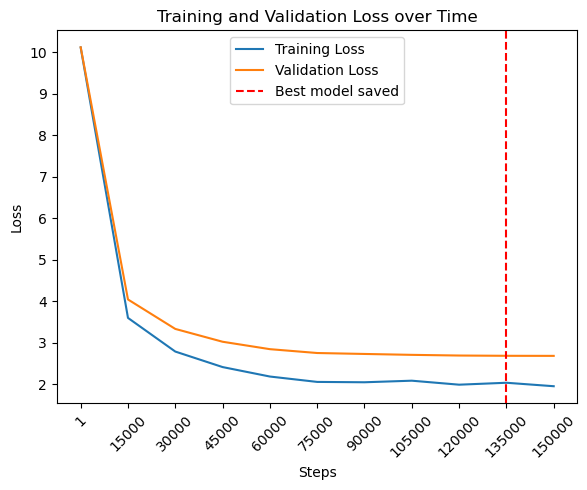

In [21]:
# Plot losses
plot_loss(
    steps=history["step"],
    training_losses=history["train_losses"],
    val_losses=history["val_losses"],
    last_model_saved_step=history["last_model_saved_step"],
    save_filepath=f"{ROOT_DIR}/results/loss_plot.png"
)

In [22]:
# Reoirt losses
report_loss(
    steps=history["step"],
    training_losses=history["train_losses"],
    val_losses=history["val_losses"],
    save_filepath=f"{ROOT_DIR}/results/loss_report.md"
)

None
